In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "ATL"
away= "GSW"

In [3]:
game_day = datetime.strptime("2025-03-02", "%Y-%m-%d")

In [4]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,MP,Tm_FG,Tm_FGA,...,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pos,Tm_Pace,Opp_Pace
64,ATL,PHI,2025-03-10,W,H,132,123,240,53,98,...,12.6,63.0,7.8,4.9,9.9,2.0,1.0,102.045825,102.045825,102.045825
65,ATL,CHO,2025-03-12,W,H,123,110,240,37,88,...,11.7,72.5,8.7,17.3,18.0,2.0,2.0,103.385900,103.385900,103.385900
66,ATL,LAC,2025-03-14,L,H,98,121,240,37,88,...,15.9,57.4,14.2,9.1,12.9,2.0,2.0,98.839185,98.839185,98.839185
67,ATL,BRK,2025-03-16,L,A,114,122,240,42,90,...,12.2,76.7,7.0,9.4,14.5,2.0,1.0,100.602660,100.602660,100.602660
68,ATL,CHO,2025-03-18,W,A,134,102,240,50,93,...,9.9,65.8,7.1,16.7,15.4,2.0,2.0,97.910205,97.910205,97.910205


In [5]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,MP,Tm_FG,Tm_FGA,...,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pos,Tm_Pace,Opp_Pace
64,PHI,ATL,2025-03-10,L,A,123,132,240,46,91,...,9.9,64.2,3.9,12.2,12.6,1.0,2.0,102.045825,102.045825,102.045825
65,CHO,ATL,2025-03-12,L,A,110,123,240,40,88,...,18.0,70.3,12.6,11.3,11.7,2.0,2.0,103.385900,103.385900,103.385900
66,LAC,ATL,2025-03-14,W,A,121,98,240,47,86,...,12.9,67.6,8.1,10.2,15.9,2.0,2.0,98.839185,98.839185,98.839185
67,BRK,ATL,2025-03-16,W,H,122,114,240,43,90,...,14.5,64.3,11.9,20.0,12.2,1.0,2.0,100.602660,100.602660,100.602660
68,CHO,ATL,2025-03-18,L,H,102,134,240,38,84,...,15.4,54.0,12.3,14.8,9.9,2.0,2.0,97.910205,97.910205,97.910205


In [6]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,MP,Tm_FG,Tm_FGA,...,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pos,Tm_Pace,Opp_Pace
65,GSW,SAC,2025-03-13,W,H,130,104,240,45,78,...,15.3,67.6,7.2,10.3,14.5,3.0,3.0,96.592215,96.592215,96.592215
66,GSW,NYK,2025-03-15,W,H,97,94,240,33,83,...,10.6,54.1,6.6,14.3,12.4,2.0,3.0,90.590985,90.590985,90.590985
67,GSW,DEN,2025-03-17,L,H,105,114,240,41,84,...,17.3,74.4,11.8,13.7,18.0,2.0,2.0,101.559985,101.559985,101.559985
68,GSW,MIL,2025-03-18,W,H,104,93,240,32,77,...,17.7,61.3,9.4,12.1,9.9,1.0,2.0,95.355875,95.355875,95.355875
69,GSW,TOR,2025-03-20,W,H,117,114,240,38,90,...,12.8,72.7,6.8,9.3,21.0,2.0,3.0,102.282080,102.282080,102.282080


In [7]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,MP,Tm_FG,Tm_FGA,...,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pos,Tm_Pace,Opp_Pace
65,SAC,GSW,2025-03-13,L,A,104,130,240,37,79,...,14.5,77.8,8.3,11.9,15.3,3.0,3.0,96.592215,96.592215,96.592215
66,NYK,GSW,2025-03-15,L,A,94,97,240,37,86,...,12.4,75.8,7.7,8.1,10.6,3.0,2.0,90.590985,90.590985,90.590985
67,DEN,GSW,2025-03-17,W,A,114,105,240,43,92,...,18.0,58.5,15.8,18.9,17.3,2.0,2.0,101.559985,101.559985,101.559985
68,MIL,GSW,2025-03-18,L,A,93,104,240,31,79,...,9.9,78.1,7.3,14.6,17.7,2.0,1.0,95.355875,95.355875,95.355875
69,TOR,GSW,2025-03-20,L,A,114,117,240,44,78,...,21.0,78.9,12.7,9.6,12.8,3.0,2.0,102.282080,102.282080,102.282080


In [8]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'Tm_PTS', 'Opp_PTS', 'MP', 'Tm_FG', 'Tm_FGA', 'Tm_FG%', 'Tm_2P', 'Tm_2PA', 'Tm_2P%', 'Tm_3P', 'Tm_3PA', 'Tm_3P%', 'Tm_FT', 'Tm_FTA', 'Tm_FT%', 'Opp_FG', 'Opp_FGA', 'Opp_FG%', 'Opp_2P', 'Opp_2PA', 'Opp_2P%', 'Opp_3P', 'Opp_3PA', 'Opp_3P%', 'Opp_FT', 'Opp_FTA', 'Opp_FT%', 'Tm_ORB', 'Tm_DRB', 'Tm_TRB', 'Opp_ORB', 'Opp_DRB', 'Opp_TRB', 'Tm_AST', 'Tm_STL', 'Tm_BLK', 'Tm_TOV', 'Tm_PF', 'Opp_AST', 'Opp_STL', 'Opp_BLK', 'Opp_TOV', 'Opp_PF', 'Tm_ORtg', 'Tm_DRtg', 'Tm_FTr', 'Tm_3PAr', 'Tm_TS%', 'Tm_eFG%', 'Tm_FT/FGA', 'Opp_ORtg', 'Opp_DRtg', 'Opp_FTr', 'Opp_3PAr', 'Opp_TS%', 'Opp_eFG%', 'Opp_FT/FGA', 'Tm_ORB%', 'Tm_DRB%', 'Tm_TRB%', 'Opp_ORB%', 'Opp_DRB%', 'Opp_TRB%', 'Tm_AST%', 'Tm_STL%', 'Tm_BLK%', 'Tm_TOV%', 'Opp_AST%', 'Opp_STL%', 'Opp_BLK%', 'Opp_TOV%', 'Tm_Rest', 'Opp_Rest', 'Tm_Pos', 'Tm_Pace', 'Opp_Pace']


# Desc

# Features

## Offense

In [9]:
offense= ['Tm_PTS', 'Tm_FGA', 'Tm_FG%', 'Tm_2PA', 'Tm_2P%', 'Tm_3PA', 'Tm_3P%', 'Tm_FTA', 'Tm_FT%', 'Tm_ORB', 'Tm_AST', 'Tm_TOV',
          'Tm_ORtg', 'Tm_FTr', 'Tm_3PAr', 'Tm_TS%', 'Tm_eFG%', 'Tm_FT/FGA', 'Tm_ORB%','Tm_AST%', 'Opp_DRB', 'Opp_STL', 'Opp_BLK', 
          'Opp_DRtg', 'Opp_DRB%', 'Opp_STL%', 'Opp_BLK%', 'Opp_TOV%', 'Tm_Pace']

In [10]:
df_home_off= df_home[offense]
df_home_off.head()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Tm_AST%,Opp_DRB,Opp_STL,Opp_BLK,Opp_DRtg,Opp_DRB%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Pace
0,120,80,0.488,52,0.577,28,0.321,46,0.717,12,...,64.1,31,8,6,115.6,72.1,7.7,11.5,15.7,103.795040
1,125,81,0.481,43,0.581,38,0.368,38,0.868,7,...,64.1,31,7,4,123.4,81.6,6.9,9.3,14.1,101.318565
2,104,91,0.396,60,0.433,31,0.323,29,0.759,17,...,66.7,34,13,12,102.7,66.7,12.8,20.0,8.8,101.238275
3,119,81,0.481,41,0.585,40,0.375,36,0.722,6,...,82.1,34,7,3,112.8,85.0,6.6,7.3,15.2,105.505000
4,120,95,0.474,56,0.589,39,0.308,21,0.857,12,...,62.2,31,10,5,112.8,72.1,9.4,8.9,13.8,106.394380


In [11]:
df_home_off.columns

Index(['Tm_PTS', 'Tm_FGA', 'Tm_FG%', 'Tm_2PA', 'Tm_2P%', 'Tm_3PA', 'Tm_3P%',
       'Tm_FTA', 'Tm_FT%', 'Tm_ORB', 'Tm_AST', 'Tm_TOV', 'Tm_ORtg', 'Tm_FTr',
       'Tm_3PAr', 'Tm_TS%', 'Tm_eFG%', 'Tm_FT/FGA', 'Tm_ORB%', 'Tm_AST%',
       'Opp_DRB', 'Opp_STL', 'Opp_BLK', 'Opp_DRtg', 'Opp_DRB%', 'Opp_STL%',
       'Opp_BLK%', 'Opp_TOV%', 'Tm_Pace'],
      dtype='object')

In [12]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.head()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Tm_AST%,Opp_DRB,Opp_STL,Opp_BLK,Opp_DRtg,Opp_DRB%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Pace
0,116,91,0.440,48,0.479,43,0.395,25,0.760,12,...,52.5,33,12,9,111.8,73.3,11.6,18.8,13.8,103.795040
1,120,96,0.385,45,0.356,51,0.412,31,0.806,22,...,59.5,32,11,9,118.5,59.3,10.9,20.0,12.5,101.318565
2,128,89,0.494,49,0.571,40,0.400,32,0.750,11,...,59.1,32,7,4,126.4,74.4,6.9,8.2,16.2,101.238275
3,121,91,0.451,47,0.426,44,0.477,22,0.818,9,...,58.5,33,12,7,114.7,78.6,11.4,14.9,14.2,105.505000
4,133,89,0.528,51,0.608,38,0.421,25,0.920,6,...,68.1,29,10,3,125.0,82.9,9.4,5.9,14.0,106.394380


In [13]:
df_away_off= df_away[offense]
df_away_off.head()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Tm_AST%,Opp_DRB,Opp_STL,Opp_BLK,Opp_DRtg,Opp_DRB%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Pace
0,140,93,0.516,45,0.622,48,0.417,30,0.800,15,...,79.2,29,10,4,130.6,65.9,9.3,8.9,14.6,107.219865
1,127,106,0.481,56,0.554,50,0.400,6,0.833,19,...,68.6,31,8,5,122.0,62.0,7.7,8.9,17.5,104.123725
2,104,88,0.432,45,0.533,43,0.326,22,0.636,14,...,50.0,34,11,2,101.9,70.8,10.8,4.4,15.2,102.036360
3,124,97,0.474,51,0.490,46,0.457,13,0.846,11,...,73.9,35,4,6,127.5,76.1,4.1,11.8,22.1,97.267495
4,104,87,0.471,49,0.571,38,0.342,13,0.692,13,...,78.0,31,7,6,114.7,70.5,7.7,12.2,13.2,90.660465


In [14]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.head()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Tm_AST%,Opp_DRB,Opp_STL,Opp_BLK,Opp_DRtg,Opp_DRB%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Pace
0,104,92,0.391,58,0.483,34,0.235,30,0.800,13,...,58.3,42,13,5,97.0,76.4,12.1,8.6,14.5,107.219865
1,86,92,0.315,50,0.400,42,0.214,26,0.731,14,...,62.1,41,15,6,82.6,74.5,14.4,12.0,12.1,104.123725
2,112,90,0.467,58,0.552,32,0.313,23,0.783,14,...,64.3,33,10,5,109.8,70.2,9.8,8.6,17.7,102.036360
3,106,74,0.541,52,0.596,22,0.409,24,0.708,9,...,57.5,23,15,9,109.0,71.9,15.4,17.3,7.2,97.267495
4,89,90,0.367,54,0.407,36,0.306,20,0.600,18,...,72.7,29,5,9,98.2,61.7,5.5,16.7,13.1,90.660465


## Defence

In [15]:
defence= ['Tm_DRB', 'Tm_STL', 'Tm_BLK', 'Tm_DRtg', 'Tm_DRB%', 'Tm_STL%', 'Tm_BLK%', 'Tm_TOV%', 'Opp_PTS', 'Opp_FGA', 'Opp_FG%', 
          'Opp_2PA', 'Opp_2P%', 'Opp_3PA', 'Opp_3P%', 'Opp_FTA', 'Opp_FT%', 'Opp_ORB', 'Opp_AST', 'Opp_TOV', 'Opp_ORtg', 'Opp_FTr', 
          'Opp_3PAr', 'Opp_TS%', 'Opp_eFG%', 'Opp_FT/FGA', 'Opp_ORB%','Opp_AST%', 'Opp_Pace']

In [16]:
df_home_def= df_home[defence]
df_home_def.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_TOV,Opp_ORtg,Opp_FTr,Opp_3PAr,Opp_TS%,Opp_eFG%,Opp_FT/FGA,Opp_ORB%,Opp_AST%,Opp_Pace
0,33,12,9,111.8,73.3,11.6,18.8,13.8,116,91,...,19,111.8,0.275,0.473,0.569,0.533,0.209,26.7,52.5,103.795040
1,32,11,9,118.5,59.3,10.9,20.0,12.5,120,96,...,18,118.5,0.323,0.531,0.547,0.495,0.260,40.7,59.5,101.318565
2,32,7,4,126.4,74.4,6.9,8.2,16.2,128,89,...,10,126.4,0.360,0.449,0.621,0.584,0.270,25.6,59.1,101.238275
3,33,12,7,114.7,78.6,11.4,14.9,14.2,121,91,...,18,114.7,0.242,0.484,0.601,0.566,0.198,21.4,58.5,105.505000
4,29,10,3,125.0,82.9,9.4,5.9,14.0,133,89,...,16,125.0,0.281,0.427,0.665,0.618,0.258,17.1,68.1,106.394380


In [17]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_TOV,Opp_ORtg,Opp_FTr,Opp_3PAr,Opp_TS%,Opp_eFG%,Opp_FT/FGA,Opp_ORB%,Opp_AST%,Opp_Pace
0,31,8,6,115.6,72.1,7.7,11.5,15.7,120,80,...,16,115.6,0.575,0.350,0.599,0.544,0.413,27.9,64.1,103.795040
1,31,7,4,123.4,81.6,6.9,9.3,14.1,125,81,...,14,123.4,0.469,0.469,0.640,0.568,0.407,18.4,64.1,101.318565
2,34,13,12,102.7,66.7,12.8,20.0,8.8,104,91,...,20,102.7,0.319,0.341,0.501,0.451,0.242,33.3,66.7,101.238275
3,34,7,3,112.8,85.0,6.6,7.3,15.2,119,81,...,16,112.8,0.444,0.494,0.614,0.574,0.321,15.0,82.1,105.505000
4,31,10,5,112.8,72.1,9.4,8.9,13.8,120,95,...,17,112.8,0.221,0.411,0.576,0.537,0.189,27.9,62.2,106.394380


In [18]:
df_away_def= df_away[defence]
df_away_def.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_TOV,Opp_ORtg,Opp_FTr,Opp_3PAr,Opp_TS%,Opp_eFG%,Opp_FT/FGA,Opp_ORB%,Opp_AST%,Opp_Pace
0,42,13,5,97.0,76.4,12.1,8.6,14.5,104,92,...,18,97.0,0.326,0.370,0.494,0.435,0.261,23.6,58.3,107.219865
1,41,15,6,82.6,74.5,14.4,12.0,12.1,86,92,...,22,82.6,0.283,0.457,0.416,0.364,0.207,25.5,62.1,104.123725
2,33,10,5,109.8,70.2,9.8,8.6,17.7,112,90,...,18,109.8,0.256,0.356,0.559,0.522,0.200,29.8,64.3,102.036360
3,23,15,9,109.0,71.9,15.4,17.3,7.2,106,74,...,24,109.0,0.324,0.297,0.627,0.601,0.230,28.1,57.5,97.267495
4,29,5,9,98.2,61.7,5.5,16.7,13.1,89,90,...,15,98.2,0.222,0.400,0.450,0.428,0.133,38.3,72.7,90.660465


In [19]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_TOV,Opp_ORtg,Opp_FTr,Opp_3PAr,Opp_TS%,Opp_eFG%,Opp_FT/FGA,Opp_ORB%,Opp_AST%,Opp_Pace
0,29,10,4,130.6,65.9,9.3,8.9,14.6,140,93,...,18,130.6,0.323,0.516,0.659,0.624,0.258,34.1,79.2,107.219865
1,31,8,5,122.0,62.0,7.7,8.9,17.5,127,106,...,15,122.0,0.057,0.472,0.584,0.575,0.047,38.0,68.6,104.123725
2,34,11,2,101.9,70.8,10.8,4.4,15.2,104,88,...,21,101.9,0.250,0.489,0.532,0.511,0.159,29.2,50.0,102.036360
3,35,4,6,127.5,76.1,4.1,11.8,22.1,124,97,...,8,127.5,0.134,0.474,0.604,0.582,0.113,23.9,73.9,97.267495
4,31,7,6,114.7,70.5,7.7,12.2,13.2,104,87,...,14,114.7,0.149,0.437,0.561,0.546,0.103,29.5,78.0,90.660465


## By Team

In [20]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    for col in target_cols:
        for lag in range(1, window+1):
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [21]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Opp_DRB%_rolling_avg_4,Opp_DRB%_rolling_std_4,Opp_STL%_rolling_avg_4,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4
64,132,98,0.541,61,0.623,37,0.405,14,0.786,14,...,70.125,8.052898,7.800,2.783283,5.850,3.485685,12.875,2.510478,102.039369,5.002494
65,123,88,0.420,52,0.442,36,0.389,39,0.897,13,...,69.900,8.253888,7.975,2.746361,5.975,3.424787,11.325,1.607016,102.735253,4.669964
66,98,88,0.420,55,0.509,33,0.273,17,0.882,13,...,68.600,6.530442,8.325,2.720754,9.875,5.301808,12.725,3.799452,101.369078,2.644858
67,114,90,0.467,53,0.585,37,0.297,24,0.792,10,...,67.925,5.833452,10.600,2.922328,10.200,5.170429,13.450,3.357082,101.706561,1.989769
68,134,93,0.538,48,0.583,45,0.489,15,0.800,11,...,70.875,4.630605,9.425,3.258195,10.175,5.175181,13.825,3.373796,101.218392,1.951281


In [22]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Opp_DRB%_rolling_avg_4,Opp_DRB%_rolling_std_4,Opp_STL%_rolling_avg_4,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4
64,123,91,0.505,49,0.612,42,0.381,20,0.750,6,...,68.925,12.693666,9.050,2.914904,11.500,3.659690,10.575,2.372586,102.039369,5.002494
65,110,88,0.455,53,0.491,35,0.400,18,0.889,10,...,77.325,7.128055,7.000,2.938253,11.625,3.677295,11.125,2.565638,102.735253,4.669964
66,121,86,0.547,59,0.593,27,0.444,20,0.750,7,...,76.075,6.938480,7.850,4.063250,11.900,3.574913,11.550,2.455606,101.369078,2.644858
67,122,90,0.478,55,0.473,35,0.486,23,0.826,12,...,77.425,7.475460,8.600,3.641428,12.525,2.709705,13.500,1.816590,101.706561,1.989769
68,102,84,0.452,54,0.519,30,0.333,21,0.762,10,...,77.900,6.706216,9.125,4.005309,13.425,4.458980,13.100,1.902630,101.218392,1.951281


In [23]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_eFG%_rolling_avg_4,Opp_eFG%_rolling_std_4,Opp_FT/FGA_rolling_avg_4,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4
65,36,8,5,107.7,87.8,8.3,11.9,15.3,104,79,...,0.53775,0.057017,0.19650,0.083958,27.925,5.667671,61.425,12.245918,99.227004,4.644715
66,35,7,5,103.8,72.9,7.7,8.1,10.6,94,86,...,0.55475,0.046871,0.21475,0.071728,23.825,9.590751,62.475,12.645256,99.213491,4.654793
67,27,16,10,112.3,58.7,15.8,18.9,17.3,114,92,...,0.52750,0.049602,0.20075,0.084124,25.325,9.491180,58.950,12.481586,97.987489,6.311613
68,43,7,6,97.5,91.5,7.3,14.6,17.7,93,79,...,0.54125,0.042051,0.15925,0.031468,28.875,12.541764,66.650,8.818352,96.911895,4.677282
69,27,13,5,111.5,79.4,12.7,9.6,12.8,114,78,...,0.51275,0.043821,0.18100,0.050774,22.275,15.016519,64.350,8.678133,96.024765,4.506811


In [24]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_eFG%_rolling_avg_4,Opp_eFG%_rolling_std_4,Opp_FT/FGA_rolling_avg_4,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4
65,25,7,4,134.6,78.1,7.2,10.3,14.5,130,78,...,0.56625,0.067544,0.28525,0.105468,29.750,6.296295,74.850,3.720663,99.227004,4.644715
66,36,6,6,107.1,78.3,6.6,14.3,12.4,97,83,...,0.60500,0.101157,0.30050,0.085831,29.150,7.057148,76.850,1.705872,99.213491,4.654793
67,34,12,7,103.4,75.6,11.8,13.7,18.0,105,84,...,0.58375,0.120550,0.26625,0.084693,24.950,3.955165,76.425,1.701715,97.987489,6.311613
68,30,9,4,109.1,76.9,9.4,12.1,9.9,104,77,...,0.59575,0.109746,0.21275,0.023215,24.500,3.866954,72.475,9.364249,96.911895,4.677282
69,37,7,4,114.4,77.1,6.8,9.3,21.0,117,90,...,0.56400,0.105969,0.23150,0.050077,22.775,1.247330,72.550,9.422137,96.024765,4.506811


In [25]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Opp_DRB%_rolling_avg_4,Opp_DRB%_rolling_std_4,Opp_STL%_rolling_avg_4,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4
65,130,78,0.577,39,0.590,39,0.564,24,0.750,7,...,70.250,6.296295,7.950,3.043572,8.650,3.284814,14.100,2.705550,99.227004,4.644715
66,97,83,0.398,42,0.476,41,0.317,22,0.818,10,...,70.850,7.057148,8.725,1.925920,10.250,0.873689,14.625,2.458150,99.213491,4.654793
67,105,84,0.488,51,0.647,33,0.242,27,0.556,11,...,75.050,3.955165,8.550,2.120535,11.325,2.160825,14.925,1.913766,97.987489,6.311613
68,104,77,0.416,33,0.455,44,0.386,26,0.885,9,...,75.500,3.866954,8.675,2.340050,12.425,1.889224,15.275,2.390781,96.911895,4.677282
69,117,90,0.422,43,0.442,47,0.404,28,0.786,11,...,77.225,1.247330,8.750,2.362908,12.600,1.792577,13.700,3.428313,96.024765,4.506811


In [26]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Opp_DRB%_rolling_avg_4,Opp_DRB%_rolling_std_4,Opp_STL%_rolling_avg_4,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4
65,104,79,0.468,42,0.548,37,0.378,22,0.727,5,...,72.075,5.667671,9.450,5.608624,9.000,2.493993,14.650,1.880603,99.227004,4.644715
66,94,86,0.430,62,0.452,24,0.375,13,0.846,13,...,76.175,9.590751,9.725,5.487182,9.000,2.493993,15.500,0.439697,99.213491,4.654793
67,114,92,0.467,53,0.547,39,0.359,18,0.778,19,...,74.675,9.491180,10.875,3.883619,9.175,2.365551,14.400,2.549510,97.987489,6.311613
68,93,79,0.392,41,0.463,38,0.316,27,0.704,4,...,71.125,12.541764,12.000,4.628175,12.275,4.682147,14.800,2.920046,96.911895,4.677282
69,114,78,0.564,52,0.635,26,0.423,19,0.789,7,...,77.725,15.016519,9.775,4.037635,13.375,4.547069,15.225,3.257172,96.024765,4.506811


In [27]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_eFG%_rolling_avg_4,Opp_eFG%_rolling_std_4,Opp_FT/FGA_rolling_avg_4,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4
64,34,4,6,120.5,85.0,3.9,12.2,12.6,123,91,...,0.54800,0.039808,0.2220,0.048035,31.075,12.693666,65.95,9.563995,102.039369,5.002494
65,30,13,6,106.4,75.0,12.6,11.3,11.7,110,88,...,0.55250,0.044606,0.2015,0.051202,22.675,7.128055,62.55,6.414827,102.735253,4.669964
66,31,8,6,122.4,81.6,8.1,10.2,15.9,121,86,...,0.54400,0.043901,0.2000,0.051814,23.925,6.938480,66.90,5.515433,101.369078,2.644858
67,28,12,11,121.3,70.0,11.9,20.0,12.2,122,90,...,0.55800,0.057521,0.1995,0.052131,22.575,7.475460,65.90,7.006188,101.706561,1.989769
68,35,12,8,104.2,77.8,12.3,14.8,9.9,102,84,...,0.57875,0.034827,0.1830,0.019916,22.100,6.706216,67.40,8.791284,101.218392,1.951281


In [28]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_eFG%_rolling_avg_4,Opp_eFG%_rolling_std_4,Opp_FT/FGA_rolling_avg_4,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4
64,25,8,3,129.4,64.1,7.8,4.9,9.9,132,98,...,0.56900,0.056309,0.14450,0.046879,29.875,8.052898,62.60,8.524866,102.039369,5.002494
65,37,9,9,119.0,74.0,8.7,17.3,18.0,123,88,...,0.56300,0.046504,0.14900,0.040898,30.100,8.253888,62.75,8.553557,102.735253,4.669964
66,33,14,5,99.1,71.7,14.2,9.1,12.9,98,88,...,0.55425,0.055877,0.21625,0.127186,31.400,6.530442,62.40,8.080842,101.369078,2.644858
67,28,7,5,113.3,73.7,7.0,9.4,14.5,114,90,...,0.52600,0.063230,0.22150,0.123875,32.075,5.833452,63.30,8.507644,101.706561,1.989769
68,29,7,8,136.9,72.5,7.1,16.7,15.4,134,93,...,0.52925,0.062809,0.22275,0.123691,29.125,4.630605,66.60,2.929164,101.218392,1.951281


In [29]:
df_home_off.drop(columns=['Tm_PTS'], inplace= True)
df_away_off.drop(columns=['Tm_PTS'], inplace= True)
df_vs_home_off.drop(columns=['Tm_PTS'], inplace= True)
df_vs_away_off.drop(columns=['Tm_PTS'], inplace= True)

df_home_def.drop(columns=['Opp_PTS'], inplace= True)
df_away_def.drop(columns=['Opp_PTS'], inplace= True)
df_vs_home_def.drop(columns=['Opp_PTS'], inplace= True)
df_vs_away_def.drop(columns=['Opp_PTS'], inplace= True)

## Final DFs

In [30]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,Tm_AST,...,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A
0,93,0.538,48,0.583,45,0.489,15,0.8,11,27,...,0.050774,22.275,15.016519,64.35,8.678133,96.024765,4.506811,-16,-18,H


In [31]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home[['Tm_Rest', 'Opp_Rest', 'H/A', 'Tm_PTS']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,Tm_AST,...,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A,Tm_PTS
0,80,0.488,52,0.577,28,0.321,46,0.717,12,25,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,2.0,H,125
1,81,0.481,43,0.581,38,0.368,38,0.868,7,25,...,27.900000,0.000000,64.100000,0.000000,103.795040,0.000000,2.0,1.0,A,104
2,91,0.396,60,0.433,31,0.323,29,0.759,17,24,...,23.150000,6.717514,64.100000,0.000000,102.556803,1.751132,1.0,2.0,H,119
3,81,0.481,41,0.585,40,0.375,36,0.722,6,32,...,26.533333,7.543430,64.966667,1.501111,102.117293,1.453526,2.0,2.0,A,120
4,95,0.474,56,0.589,39,0.308,21,0.857,12,28,...,23.650000,8.437417,69.250000,8.653901,102.964220,2.068243,2.0,3.0,H,115


In [32]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_FGA,Opp_FG%,...,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A
0,35,12,8,104.2,77.8,12.3,14.8,9.9,84,0.452,...,2.362908,12.6,1.792577,13.7,3.428313,96.024765,4.506811,-16,-18,H


In [33]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home[['Tm_Rest', 'Opp_Rest', 'H/A', 'Opp_PTS']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_FGA,Opp_FG%,...,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A,Opp_PTS
0,33,12,9,111.8,73.3,11.6,18.8,13.8,91,0.440,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,2.0,H,120
1,32,11,9,118.5,59.3,10.9,20.0,12.5,96,0.385,...,18.800000,0.000000,13.800000,0.000000,103.795040,0.000000,2.0,1.0,A,128
2,32,7,4,126.4,74.4,6.9,8.2,16.2,89,0.494,...,19.400000,0.848528,13.150000,0.919239,102.556803,1.751132,1.0,2.0,H,121
3,33,12,7,114.7,78.6,11.4,14.9,14.2,91,0.451,...,15.666667,6.494100,14.166667,1.877054,102.117293,1.453526,2.0,2.0,A,133
4,29,10,3,125.0,82.9,9.4,5.9,14.0,89,0.528,...,15.475000,5.316249,14.175000,1.532699,102.964220,2.068243,2.0,3.0,H,123


In [34]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,Tm_AST,...,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A
0,90,0.422,43,0.442,47,0.404,28,0.786,11,30,...,0.019916,22.1,6.706216,67.4,8.791284,101.218392,1.951281,-18,-16,A


In [35]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_away[['Tm_Rest', 'Opp_Rest', 'H/A', 'Tm_PTS']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,Tm_AST,...,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A,Tm_PTS
0,93,0.516,45,0.622,48,0.417,30,0.800,15,38,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,2.0,A,127
1,106,0.481,56,0.554,50,0.400,6,0.833,19,35,...,34.100000,0.000000,79.200000,0.000000,107.219865,0.000000,2.0,1.0,H,104
2,88,0.432,45,0.533,43,0.326,22,0.636,14,19,...,36.050000,2.757716,73.900000,7.495332,105.671795,2.189302,2.0,2.0,H,124
3,97,0.474,51,0.490,46,0.457,13,0.846,11,34,...,33.766667,4.409460,65.933333,14.781520,104.459983,2.608061,1.0,1.0,H,104
4,87,0.471,49,0.571,38,0.342,13,0.692,13,32,...,31.300000,6.107373,67.925000,12.709413,102.661861,4.179429,3.0,2.0,A,127


In [36]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_FGA,Opp_FG%,...,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A
0,27,13,5,111.5,79.4,12.7,9.6,12.8,78,0.564,...,3.258195,10.175,5.175181,13.825,3.373796,101.218392,1.951281,-18,-16,H


In [37]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1], 
                       df_away[['Tm_Rest', 'Opp_Rest', 'H/A', 'Opp_PTS']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_FGA,Opp_FG%,...,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A,Opp_PTS
0,42,13,5,97.0,76.4,12.1,8.6,14.5,92,0.391,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,2.0,A,86
1,41,15,6,82.6,74.5,14.4,12.0,12.1,92,0.315,...,8.600000,0.000000,14.500000,0.000000,107.219865,0.000000,2.0,1.0,H,112
2,33,10,5,109.8,70.2,9.8,8.6,17.7,90,0.467,...,10.300000,2.404163,13.300000,1.697056,105.671795,2.189302,2.0,2.0,H,106
3,23,15,9,109.0,71.9,15.4,17.3,7.2,74,0.541,...,9.733333,1.962991,14.766667,2.809508,104.459983,2.608061,1.0,1.0,H,89
4,29,5,9,98.2,61.7,5.5,16.7,13.1,90,0.367,...,11.625000,4.108832,12.875000,4.424459,102.661861,4.179429,3.0,2.0,A,121


In [38]:
df_home_gf = df_home_gf.fillna(0)

In [39]:
df_home_ga = df_home_ga.fillna(0)

In [40]:
df_away_ga = df_away_ga.fillna(0)

In [41]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [42]:
# Define bins for football goals classification
bins = [0, 90, 100, 105, 110, 115, 120, 125, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4, 5, 6, 7]  # Assigning numeric class labels

# Apply binning
df_home_gf['Tm_PTS_C'] = pd.cut(df_home_gf['Tm_PTS'], bins=bins, labels=labels)
df_away_gf['Tm_PTS_C'] = pd.cut(df_away_gf['Tm_PTS'], bins=bins, labels=labels)
df_home_ga['Opp_PTS_C'] = pd.cut(df_home_ga['Opp_PTS'], bins=bins, labels=labels)
df_away_ga['Opp_PTS_C'] = pd.cut(df_away_ga['Opp_PTS'], bins=bins, labels=labels)

In [43]:
df_home_gf.drop(columns=['Tm_PTS'], inplace= True)
df_away_gf.drop(columns=['Tm_PTS'], inplace= True)

df_home_ga.drop(columns=['Opp_PTS'], inplace= True)
df_away_ga.drop(columns=['Opp_PTS'], inplace= True)


# Models

## Classification

### Model Home

In [44]:
target = "Tm_PTS_C"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [45]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [46]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

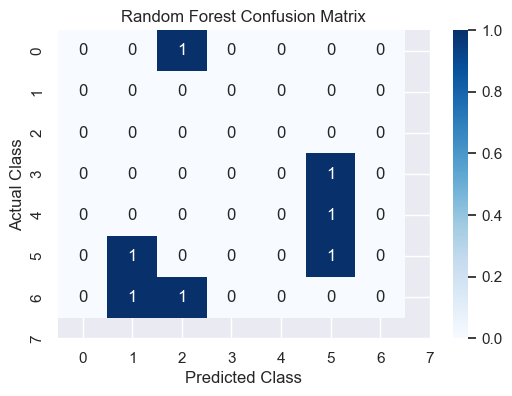

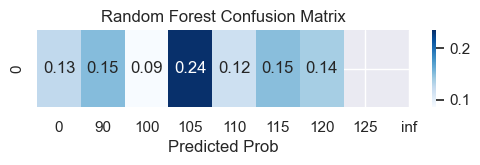

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6], got [1 2 3 4 5 6 7]

In [47]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=bins)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [48]:
target = "Opp_PTS_C"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

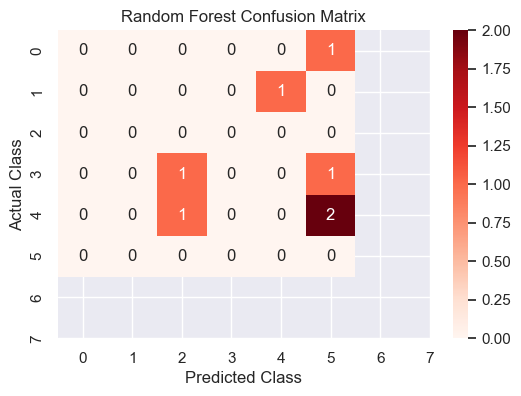

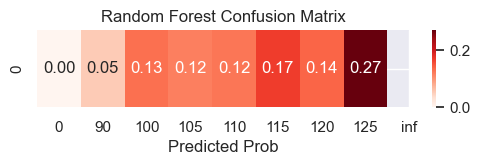

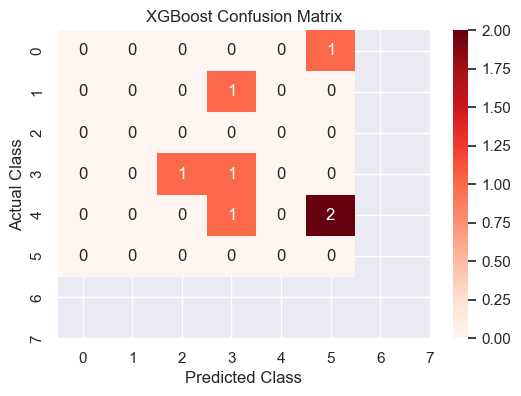

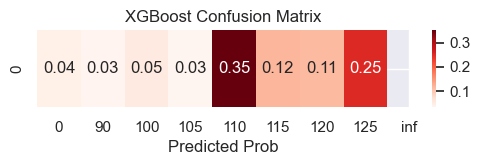

In [51]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=bins)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [52]:
target = "Tm_PTS_C"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [53]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [54]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

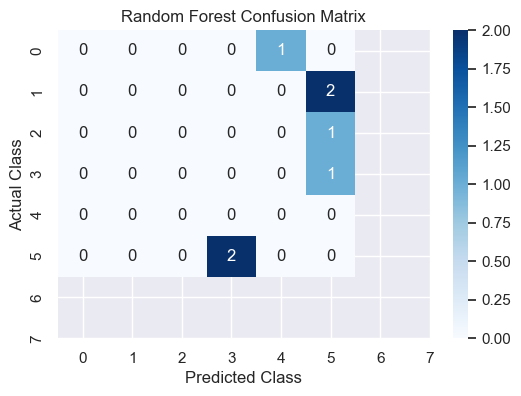

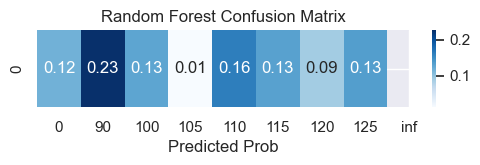

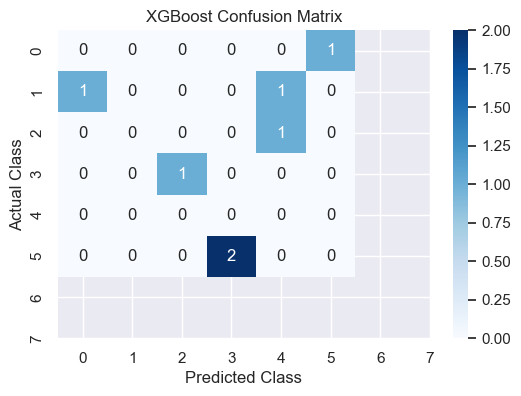

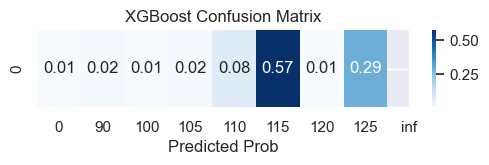

In [55]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=bins)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [56]:
target = "Opp_PTS_C"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [57]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [58]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

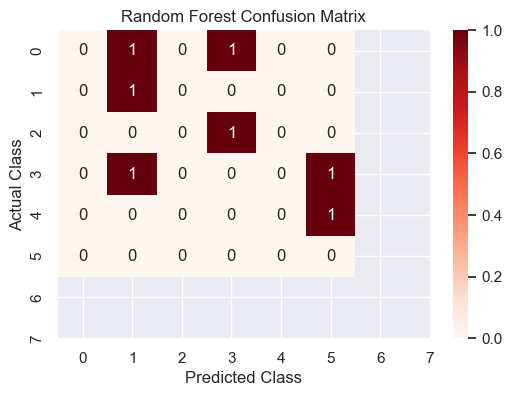

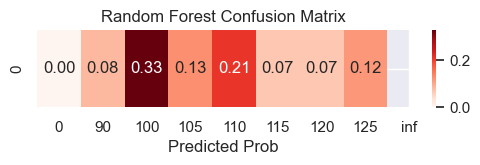

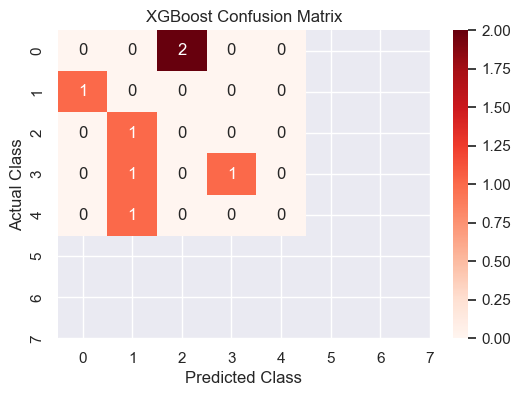

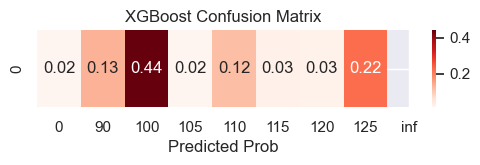

In [59]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=bins)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

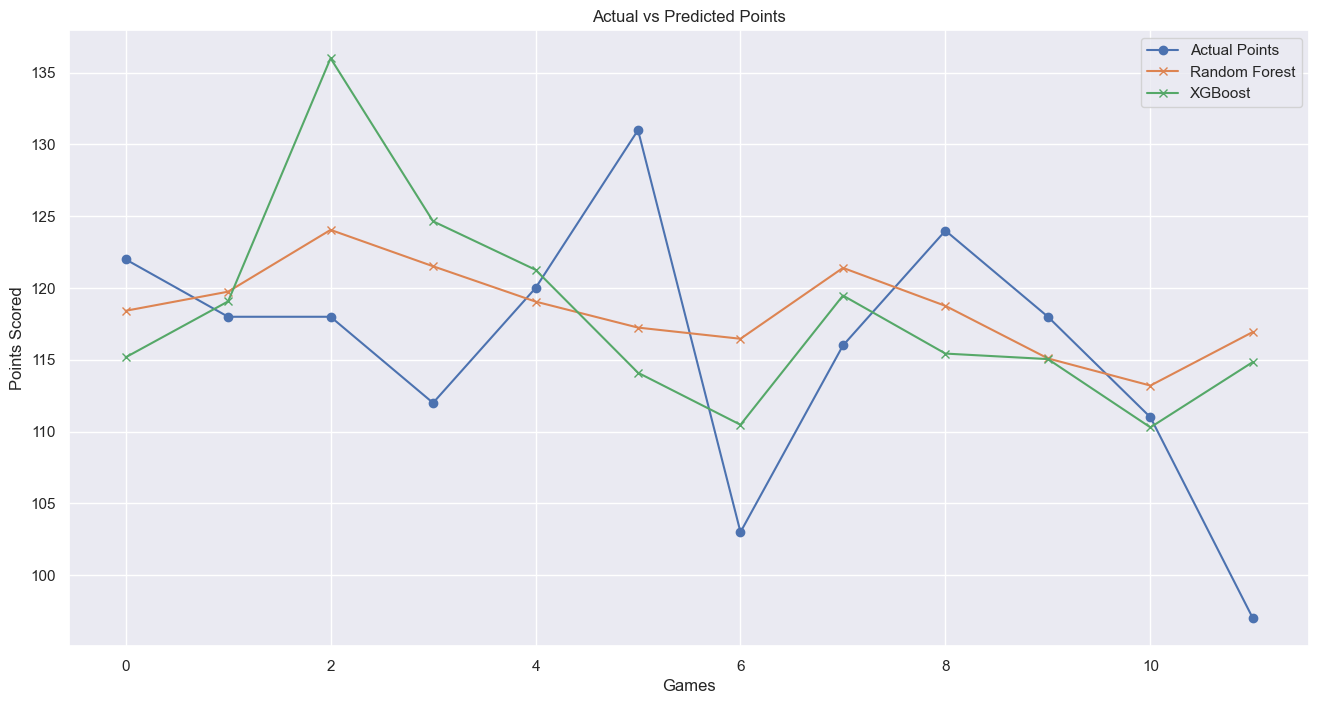

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
